# Ridge Baseline Comparison

This notebook checks the processed Tg splits, compares their distributions, and evaluates closed-form Ridge regression over several regularization strengths.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

/media/ssd4to/Documents/EPFL/EPFL/MA2/AI4Chem_Project/AI4Chem


In [2]:
import csv
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from src.data_utils import (
    TRAIN_DATA_PATH,
    VALIDATION_DATA_PATH,
    TEST_DATA_PATH,
    TARGET_COLUMN,
    RELIABILITY_COLUMN,
    load_tg_csv,
)
from src.featurize import psmiles_to_nparray
from src.models import LinearRegressionClosedForm, RidgeRegressionClosedForm
from src.train import evaluate_predictions, fit_and_predict

plt.style.use("default")

## Load Processed Splits

In [3]:
train_psmiles, y_train = load_tg_csv(TRAIN_DATA_PATH)
validation_psmiles, y_validation = load_tg_csv(VALIDATION_DATA_PATH)
test_psmiles, y_test = load_tg_csv(TEST_DATA_PATH)

print("train", len(train_psmiles), y_train.shape)
print("validation", len(validation_psmiles), y_validation.shape)
print("test", len(test_psmiles), y_test.shape)

train 5154 (5154,)
validation 1104 (1104,)
test 1105 (1105,)


In [4]:
def summarize_split(path):
    with path.open(newline="", encoding="utf-8") as file:
        rows = list(csv.DictReader(file))

    tg_values = np.array([float(row[TARGET_COLUMN]) for row in rows])
    reliability_counts = Counter(row[RELIABILITY_COLUMN] for row in rows)
    return {
        "n_rows": len(rows),
        "tg_mean": tg_values.mean(),
        "tg_std": tg_values.std(),
        "tg_min": tg_values.min(),
        "tg_max": tg_values.max(),
        "reliability_counts": reliability_counts,
    }

split_summaries = {
    "train": summarize_split(TRAIN_DATA_PATH),
    "validation": summarize_split(VALIDATION_DATA_PATH),
    "test": summarize_split(TEST_DATA_PATH),
}

for split_name, summary in split_summaries.items():
    print(split_name)
    print("  rows:", summary["n_rows"])
    print("  Tg mean/std:", round(summary["tg_mean"], 2), round(summary["tg_std"], 2))
    print("  Tg min/max:", round(summary["tg_min"], 2), round(summary["tg_max"], 2))
    print("  reliability:", dict(summary["reliability_counts"]))

train
  rows: 5154
  Tg mean/std: 416.78 112.94
  Tg min/max: 134.15 768.15
  reliability: {'black': 4962, 'yellow': 92, 'gold': 100}
validation
  rows: 1104
  Tg mean/std: 415.73 113.29
  Tg min/max: 149.0 701.15
  reliability: {'black': 1063, 'yellow': 20, 'gold': 21}
test
  rows: 1105
  Tg mean/std: 419.83 111.04
  Tg min/max: 144.15 763.15
  reliability: {'black': 1063, 'gold': 22, 'yellow': 20}


## Compare Tg and Reliability Distributions

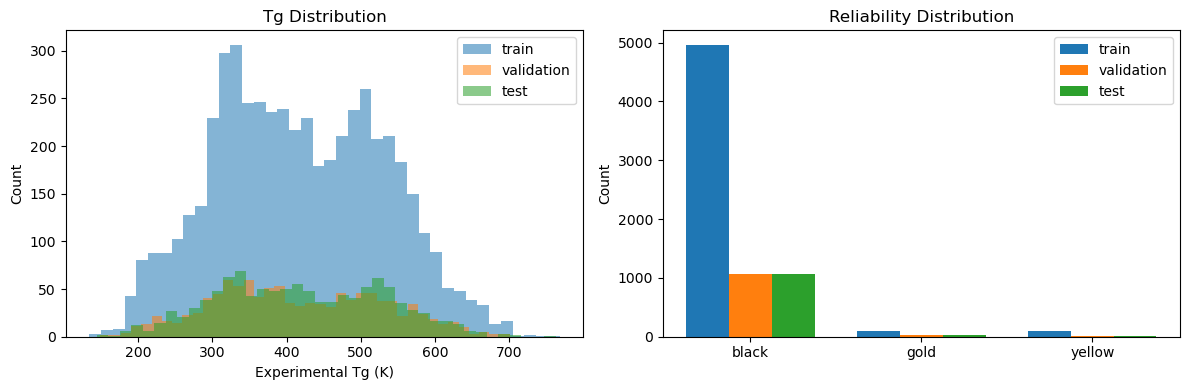

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=40, alpha=0.55, label="train")
axes[0].hist(y_validation, bins=40, alpha=0.55, label="validation")
axes[0].hist(y_test, bins=40, alpha=0.55, label="test")
axes[0].set_xlabel("Experimental Tg (K)")
axes[0].set_ylabel("Count")
axes[0].set_title("Tg Distribution")
axes[0].legend()

reliability_labels = sorted({
    label
    for summary in split_summaries.values()
    for label in summary["reliability_counts"]
})
x = np.arange(len(reliability_labels))
width = 0.25

for offset, split_name in zip([-width, 0, width], ["train", "validation", "test"]):
    counts = [split_summaries[split_name]["reliability_counts"].get(label, 0) for label in reliability_labels]
    axes[1].bar(x + offset, counts, width=width, label=split_name)

axes[1].set_xticks(x)
axes[1].set_xticklabels(reliability_labels)
axes[1].set_ylabel("Count")
axes[1].set_title("Reliability Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## Featurize PSMILES

In [6]:
X_train = psmiles_to_nparray(train_psmiles)
X_validation = psmiles_to_nparray(validation_psmiles)
X_test = psmiles_to_nparray(test_psmiles)

print("X_train", X_train.shape)
print("X_validation", X_validation.shape)
print("X_test", X_test.shape)
print("active bits per train molecule: mean/min/max", X_train.sum(axis=1).mean(), X_train.sum(axis=1).min(), X_train.sum(axis=1).max())

X_train (5154, 2048)
X_validation (1104, 2048)
X_test (1105, 2048)
active bits per train molecule: mean/min/max 39.83236321303842 6 114


## OLS Sanity Check

Closed-form OLS may fail because Morgan fingerprint columns can be linearly dependent, making `X.T @ X` singular.

In [7]:
try:
    ols_model = LinearRegressionClosedForm()
    y_pred_validation, y_pred_test = fit_and_predict(ols_model, X_train, y_train, X_validation, X_test)
    ols_scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
    print(ols_scores)
except np.linalg.LinAlgError as error:
    print("OLS failed:", error)

OLS failed: Singular matrix


## Ridge Alpha Sweep

In [8]:
alphas = np.logspace(-4, 4, 17)
ridge_results = []

for alpha in alphas:
    model = RidgeRegressionClosedForm(alpha=alpha)
    y_pred_validation, y_pred_test = fit_and_predict(model, X_train, y_train, X_validation, X_test)
    scores = evaluate_predictions(y_validation, y_pred_validation, y_test, y_pred_test)
    scores["alpha"] = alpha
    ridge_results.append(scores)

best_result = min(ridge_results, key=lambda result: result["rmse_validation"])
best_alpha = best_result["alpha"]

print("Best alpha by validation RMSE:", best_alpha)
for key, value in best_result.items():
    print(f"{key}: {value:.4f}")

Best alpha by validation RMSE: 10.0
mse_validation: 1781.0965
mse_test: 2000.4887
mae_validation: 31.4494
mae_test: 31.9435
rmse_validation: 42.2030
rmse_test: 44.7268
r2_validation: 0.8612
r2_test: 0.8377
alpha: 10.0000


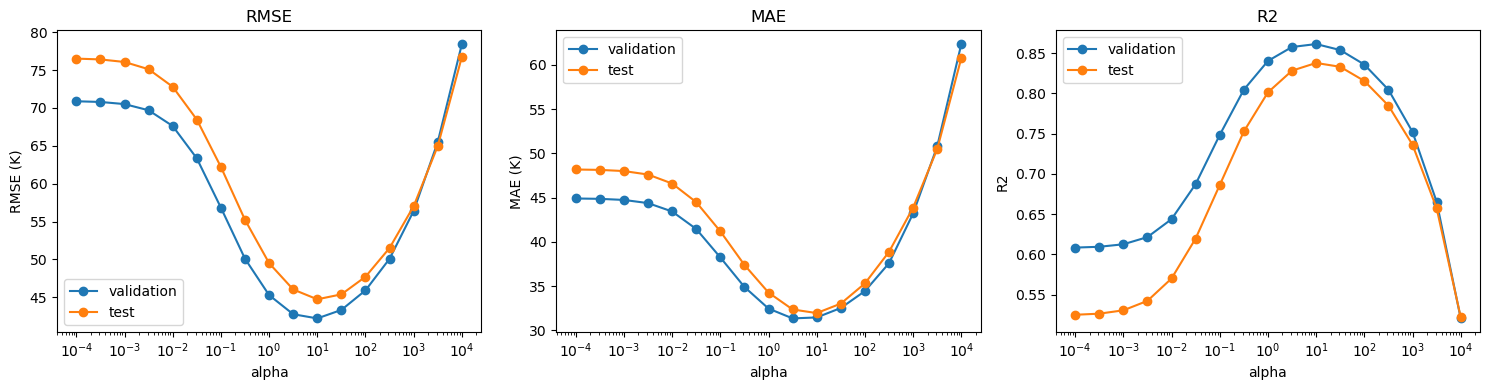

In [9]:
alpha_values = np.array([result["alpha"] for result in ridge_results])
validation_rmse = np.array([result["rmse_validation"] for result in ridge_results])
test_rmse = np.array([result["rmse_test"] for result in ridge_results])
validation_mae = np.array([result["mae_validation"] for result in ridge_results])
test_mae = np.array([result["mae_test"] for result in ridge_results])
validation_r2 = np.array([result["r2_validation"] for result in ridge_results])
test_r2 = np.array([result["r2_test"] for result in ridge_results])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(alpha_values, validation_rmse, marker="o", label="validation")
axes[0].plot(alpha_values, test_rmse, marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("RMSE (K)")
axes[0].set_title("RMSE")
axes[0].legend()

axes[1].plot(alpha_values, validation_mae, marker="o", label="validation")
axes[1].plot(alpha_values, test_mae, marker="o", label="test")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("MAE (K)")
axes[1].set_title("MAE")
axes[1].legend()

axes[2].plot(alpha_values, validation_r2, marker="o", label="validation")
axes[2].plot(alpha_values, test_r2, marker="o", label="test")
axes[2].set_xscale("log")
axes[2].set_xlabel("alpha")
axes[2].set_ylabel("R2")
axes[2].set_title("R2")
axes[2].legend()

plt.tight_layout()
plt.show()

## Best Ridge Predictions

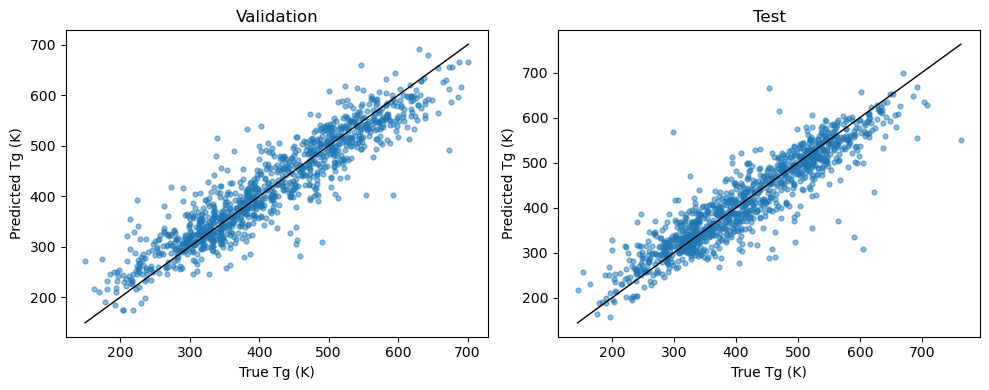

In [10]:
best_model = RidgeRegressionClosedForm(alpha=best_alpha)
y_pred_validation, y_pred_test = fit_and_predict(best_model, X_train, y_train, X_validation, X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_validation, y_pred_validation, "Validation"),
    (axes[1], y_test, y_pred_test, "Test"),
]:
    ax.scatter(y_true, y_pred, s=12, alpha=0.5)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_xlabel("True Tg (K)")
    ax.set_ylabel("Predicted Tg (K)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

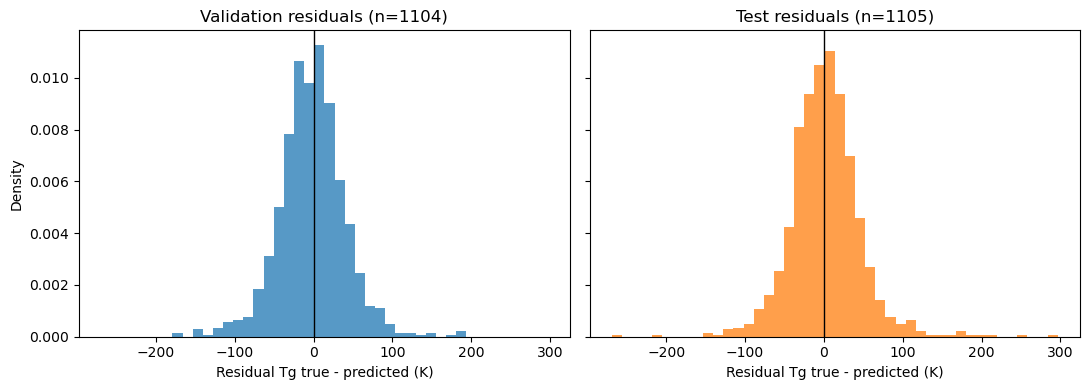

In [14]:
validation_residuals = y_validation - y_pred_validation
test_residuals = y_test - y_pred_test
all_residuals = np.concatenate([validation_residuals, test_residuals])
common_bins = np.linspace(all_residuals.min(), all_residuals.max(), 45)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

axes[0].hist(validation_residuals, bins=common_bins, density=True, alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Validation residuals (n={len(validation_residuals)})")
axes[0].set_xlabel("Residual Tg true - predicted (K)")
axes[0].set_ylabel("Density")

axes[1].hist(test_residuals, bins=common_bins, density=True, alpha=0.75, color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Test residuals (n={len(test_residuals)})")
axes[1].set_xlabel("Residual Tg true - predicted (K)")

plt.tight_layout()
plt.show()